# CA5 - BMW Used Car Price Prediction
**Name:** Mehdi [Efternamn]  
**Kaggle username:** [ditt användarnamn om det skiljer sig]

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error

In [2]:
train = pd.read_csv("C:/Users/mehdi/OneDrive/Skrivbord/Dat200/CA51/train.csv")
test  = pd.read_csv("C:/Users/mehdi/OneDrive/Skrivbord/Dat200/CA51/test.csv")
sub   = pd.read_csv("C:/Users/mehdi/OneDrive/Skrivbord/Dat200/CA51/sample_submission.csv")

print(train.shape, test.shape)

(4000, 21) (1000, 20)


In [3]:
train.head()

,car_id,model,year,engine_size,horsepower,fuel_type,transmission,drivetrain,mileage_km,fuel_consumption_l_per_100km,...,price_usd,doors,seats,body_type,color,owner_count,accident_history,service_history,country_sold,ID
0,9298,1 Series,2012,2.1,184,hybrid,automatic,FWD,246543,4.6,...,9439,5,5,hatchback,black,2.0,yes,full,UK,4227
1,4697,Z4,2018,2.9,281,petrol,automatic,RWD,98238,9.4,...,54589,2,2,convertible,white,2.0,no,partial,Netherlands,4676
2,6635,5 Series,2008,3.1,297,petrol,automatic,AWD,300000,9.0,...,23239,4,5,sedan,silver,4.0,yes,full,Turkey,800
3,1723,7 Series,2022,3.6,355,petrol,automatic,RWD,8937,11.5,...,101879,4,4,sedan,blue,1.0,NaN,partial,USA,3671
4,8626,Z4,2023,3.0,263,petrol,automatic,RWD,5778,9.4,...,77988,2,2,convertible,black,1.0,no,full,Netherlands,4193


In [4]:
print(train.isnull().sum())
train.describe() # check missing values

car_id                            0
model                             0
year                              0
engine_size                      92
horsepower                        0
fuel_type                         0
transmission                     96
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    111
co2_emissions_g_km               78
price_usd                         0
doors                             0
seats                             0
body_type                         0
color                            97
owner_count                     107
accident_history                101
service_history                  86
country_sold                      0
ID                                0
dtype: int64


,car_id,year,engine_size,horsepower,mileage_km,fuel_consumption_l_per_100km,co2_emissions_g_km,price_usd,doors,seats,owner_count,ID
count,4000.000000,4000.000000,3908.000000,4000.000000,4000.000000,3889.000000,3922.000000,4000.00000,4000.00000,4000.000000,3893.000000,4000.000000
mean,4936.066500,2016.367500,2.494959,269.998500,113302.692500,6.597994,144.697348,50585.76650,4.30525,4.725000,1.939378,2507.711000
std,2898.891051,5.444341,1.204083,80.194054,87098.910414,3.023705,67.020344,30801.00627,0.77603,0.692817,1.396635,1435.558218
min,1.000000,2005.000000,0.000000,121.000000,0.000000,0.000000,0.000000,2640.00000,2.00000,2.000000,0.000000,0.000000
25%,2417.500000,2012.000000,2.000000,212.000000,39706.500000,5.400000,118.000000,28982.25000,4.00000,5.000000,1.000000,1275.750000
50%,4890.500000,2017.000000,2.600000,260.000000,95459.000000,7.200000,158.500000,44791.00000,4.00000,5.000000,2.000000,2499.500000
75%,7446.500000,2021.000000,3.300000,319.000000,172908.750000,8.700000,191.000000,64109.25000,5.00000,5.000000,3.000000,3757.250000
max,9999.000000,2024.000000,5.000000,682.000000,300000.000000,12.800000,286.000000,213851.00000,5.00000,5.000000,5.000000,4999.000000


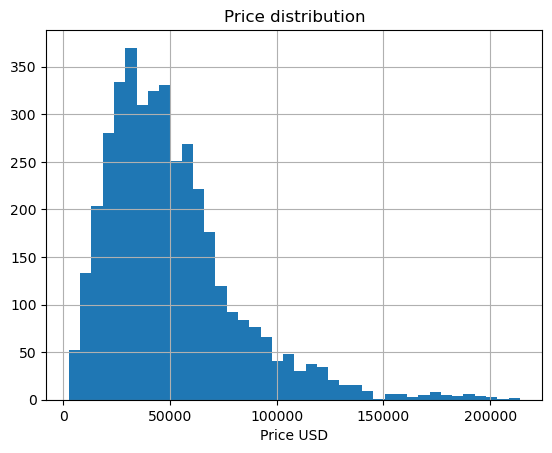

In [5]:
# just checking how prices are distributed
train["price_usd"].hist(bins=40)
plt.xlabel("Price USD")
plt.title("Price distribution")
plt.show()

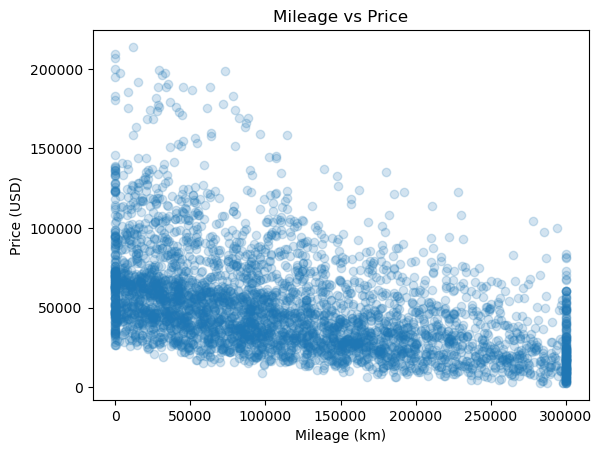

In [6]:
plt.scatter(train["mileage_km"], train["price_usd"], alpha=0.2)
plt.xlabel("Mileage (km)")
plt.ylabel("Price (USD)")
plt.title("Mileage vs Price")
plt.show()


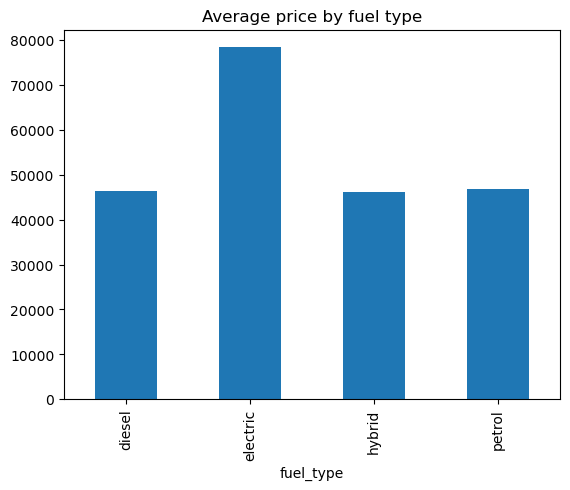

In [7]:
train.groupby("fuel_type")["price_usd"].mean().plot(kind="bar")
plt.title("Average price by fuel type")
plt.show()

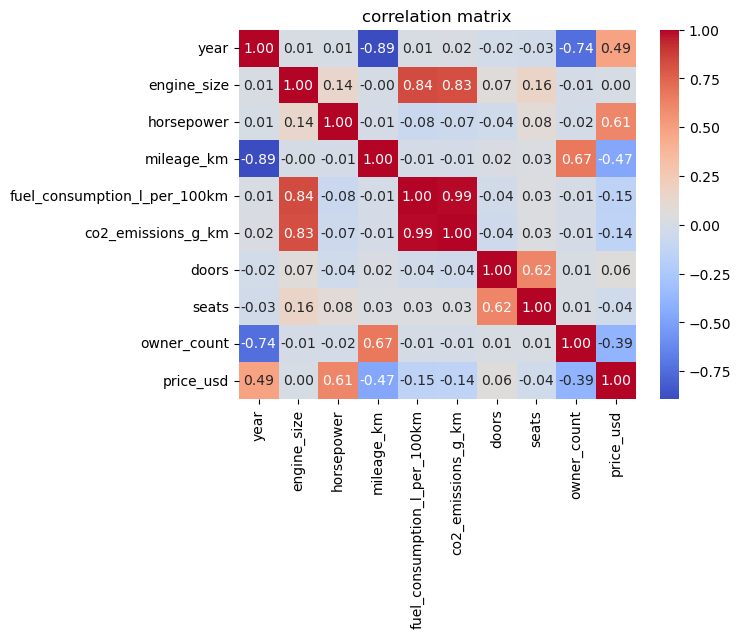

In [8]:
# correlation heatmap - checking which features relate most to price
num_cols_check = ["year", "engine_size", "horsepower", "mileage_km",
                  "fuel_consumption_l_per_100km", "co2_emissions_g_km",
                  "doors", "seats", "owner_count", "price_usd"]

corr = train[num_cols_check].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("correlation matrix")
plt.show()
# horsepower and engine_size correlate most with price


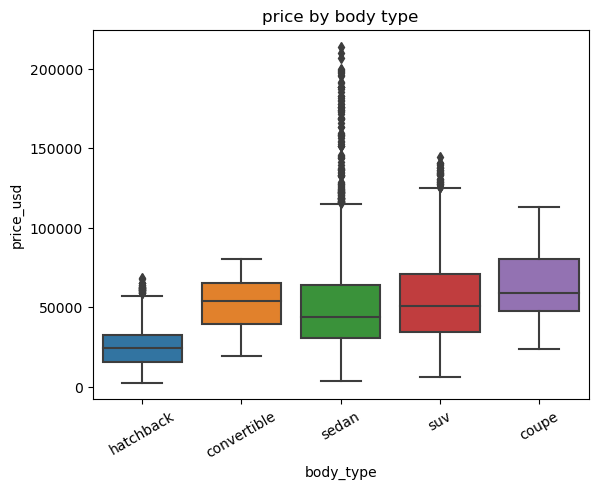

In [9]:
# boxplot to check price per body type
sns.boxplot(data=train, x="body_type", y="price_usd")
plt.xticks(rotation=30)
plt.title("price by body type")
plt.show()
# suv and coupe tend to be more expensive

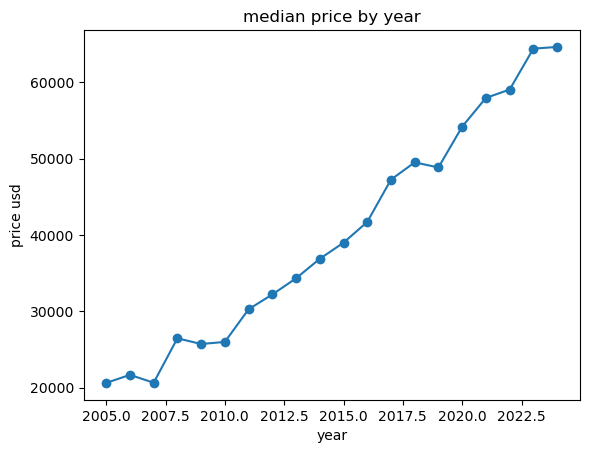

In [10]:
# price vs year - newer cars are more expensive, makes sense
train.groupby("year")["price_usd"].median().plot(marker="o")
plt.title("median price by year")
plt.ylabel("price usd")
plt.show()

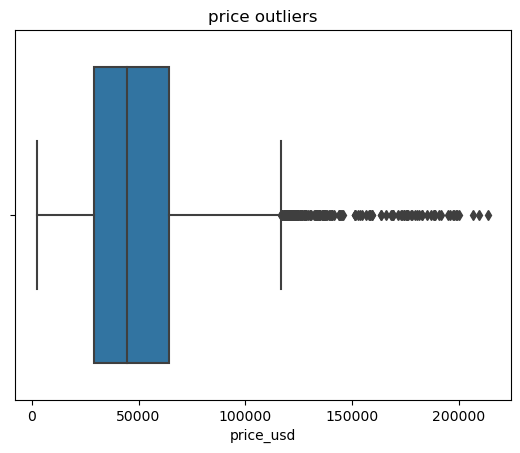

99th percentile: 163352.53


In [11]:
# check for outliers in price
sns.boxplot(x=train["price_usd"])
plt.title("price outliers")
plt.show()

# there are some very expensive cars way above the rest
print("99th percentile:", train["price_usd"].quantile(0.99))

In [24]:
train = pd.read_csv("C:/Users/mehdi/OneDrive/Skrivbord/Dat200/CA51/train.csv")
q99 = train["price_usd"].quantile(0.99)
train = train[train["price_usd"] <= q99].copy()

# adding age as a new feature
train["age"] = 2026 - train["year"]
test["age"]  = 2026 - test["year"]

# maybe mileage per year is more useful than just total mileage
train["mileage_per_year"] = train["mileage_km"] / (train["age"] + 1)
test["mileage_per_year"]  = test["mileage_km"]  / (test["age"] + 1)

# power per liter - might help
train["power_per_liter"] = train["horsepower"] / (train["engine_size"] + 0.1)
test["power_per_liter"]  = test["horsepower"]  / (test["engine_size"] + 0.1)

#newer and more powerfull cars should cost more
train["hp_x_year"] = train["horsepower"] * train["year"]
test["hp_x_year"] = test["horsepower"] * test["year"]
print("rows after cleaning:", len(train))


rows after cleaning: 3960


In [25]:
# drop columns we should not use for prediction
X = train.drop(["price_usd", "ID", "car_id"], axis=1)
y = train["price_usd"]

X_test = test.drop(["ID", "car_id"], axis=1)

# separate numeric and categorical columns
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['year', 'engine_size', 'horsepower', 'mileage_km',
       'fuel_consumption_l_per_100km', 'co2_emissions_g_km', 'doors', 'seats',
       'owner_count', 'age', 'mileage_per_year', 'power_per_liter',
       'hp_x_year'],
      dtype='object')
Categorical columns: Index(['model', 'fuel_type', 'transmission', 'drivetrain', 'body_type',
       'color', 'accident_history', 'service_history', 'country_sold'],
      dtype='object')


In [26]:
# Preprocessing pipeline

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

print("Preprocessing ready!")

Preprocessing ready!


In [27]:
# first model: ridge regression
ridge_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", Ridge())
])

ridge_search = GridSearchCV(ridge_pipe, {"regressor__alpha": [0.1, 1, 10, 100]}, cv=5, scoring="neg_mean_absolute_error")
ridge_search.fit(X, y)

print("best alpha:", ridge_search.best_params_)
print("ridge MAE:", round(-ridge_search.best_score_, 2))


best alpha: {'regressor__alpha': 0.1}
ridge MAE: 4313.55


In [28]:
# model 2 
# 4 bins with qcut (equal frequency)
y_class = pd.qcut(train["price_usd"], q = 4, labels = ["cheap", "medium", "expensive", "very_expensive"])

clf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(random_state = 42))
])
clf_search = GridSearchCV(clf_pipe, {"clf__n_estimators": [100,200], "clf__max_depth":[10,None]}, cv = 5, scoring = "accuracy")
clf_search.fit(X, y_class)

print("accuracy:", round(clf_search.best_score_, 4))

accuracy: 0.8477


In [17]:
#testing how many bins affect accurancy
for n in [2,3,4,5,6]:
    y_binned = pd.qcut(train["price_usd"], q = n, labels = False)
    acc = cross_val_score(clf_pipe, X, y_binned, cv=3, scoring = "accuracy").mean()
    print(f"{n} bins ->  {acc:.2%}")

2 bins ->  94.60%
3 bins ->  90.43%
4 bins ->  84.55%
5 bins ->  80.83%
6 bins ->  77.20%


In [29]:
# random forest to see if it beats ridge
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestRegressor(random_state=42))
])

# trying more params this time
rf_search = GridSearchCV(rf_pipe, {
    "rf__n_estimators": [200, 300],
    "rf__max_depth": [20, None],
    "rf__min_samples_split": [2, 5],
    "rf__min_samples_leaf": [1, 2]
}, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
rf_search.fit(X, y)

print(rf_search.best_params_)
print("MAE:", round(-rf_search.best_score_, 2))


{'rf__max_depth': 20, 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 2, 'rf__n_estimators': 300}
MAE: 3747.68


In [30]:
# trying gradient boosting to see if it beats rf
from sklearn.ensemble import GradientBoostingRegressor

gb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("gb", GradientBoostingRegressor(random_state=42))
])

gb_search = GridSearchCV(gb_pipe, {
    "gb__n_estimators": [200, 300],
    "gb__max_depth": [3, 5],
    "gb__learning_rate": [0.05, 0.1]
}, cv=5, scoring="neg_mean_absolute_error", n_jobs=-1)
gb_search.fit(X, y)

print(gb_search.best_params_)
print("MAE:", round(-gb_search.best_score_, 2))


{'gb__learning_rate': 0.1, 'gb__max_depth': 3, 'gb__n_estimators': 300}
MAE: 3039.41


In [31]:
# cheking whitch model did better
print("ridge:", round(-ridge_search.best_score_, 2))
print("rf:", round(-rf_search.best_score_, 2))
print("gb:", round(-gb_search.best_score_, 2))

# gb got lower MAE so using that


ridge: 4313.55
rf: 3747.68
gb: 3039.41


In [21]:
# best model is random forest - it got lower MAE than ridge
# using rf for the kaggle submission


In [22]:
# gb got better MAE so using that
y_pred = gb_search.predict(X_test)
sub["price_usd"] = y_pred
sub.to_csv("submission.csv", index=False)
print("done")
sub.head()


done


,ID,price_usd
0,1501,64216.103575
1,2586,23905.573229
2,2653,46584.478074
3,1055,24308.613006
4,705,16731.101132
